<a href="https://colab.research.google.com/github/Chosencodes/Left-Atrium-Segmentation-from-3D-Cardiac-MRI/blob/main/Atrium_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from tqdm.notebook import tqdm
from pathlib import Path

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
root = Path("/content/drive/MyDrive/Atrium-Segmentation/Task02_Heart/imagesTr")
label = Path("/content/drive/MyDrive/Atrium-Segmentation/Task02_Heart/labelsTr")

In [4]:
sample_path = next(root.glob("la*.nii.gz"))

In [5]:
sample_path_label = label / sample_path.name

In [7]:
data = nib.load(sample_path)
label = nib.load(sample_path_label)

mri = data.get_fdata()
mask = label.get_fdata().astype(np.uint8)

In [8]:
mri.shape,mask.shape

((320, 320, 130), (320, 320, 130))

In [9]:
nib.aff2axcodes(data.affine)

('R', 'A', 'S')

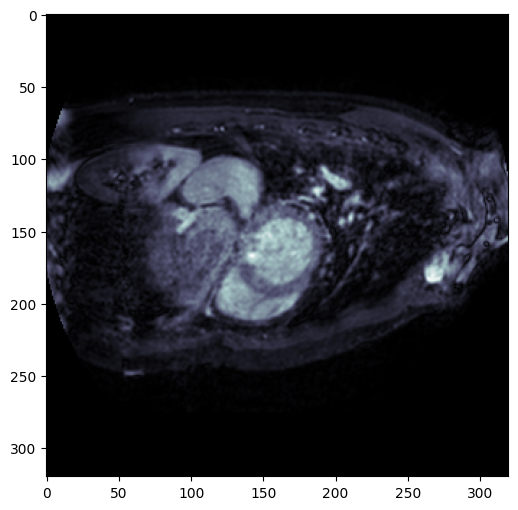

In [10]:
slice_num = 40

plt.figure(figsize=(6,6))
plt.imshow(mri[:,:,slice_num], cmap="bone")

mask_ = np.ma.masked_where(mask[:,:,slice_num] == 0,
                           mask[:,:,slice_num])

plt.imshow(mask_, alpha=0.5, cmap="autumn")

plt.show()

# **Preprocessing and Creating the Dataset**

In [11]:
!pip install torchio nibabel scikit-learn tqdm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.6/203.6 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 17.2 MB/s eta 0:00:00


In [12]:
import torchio as tio
import torch
from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

In [13]:
root = Path("/content/drive/MyDrive/Atrium-Segmentation/Task02_Heart/imagesTr")
label = Path("/content/drive/MyDrive/Atrium-Segmentation/Task02_Heart/labelsTr")

In [14]:
image_path = sorted(root.glob("*.nii.gz"))
label_path = sorted(label.glob("*.nii.gz"))

In [15]:
def make_subjects(image_path, label_path):
  subjects = []

  for img_path,lbl_path in zip(image_path, label_path):
    subject = tio.Subject(
        mri = tio.ScalarImage(img_path),
        label = tio.LabelMap(lbl_path)
    )
    subjects.append(subject)
  return subjects

all_subjects = make_subjects(image_path, label_path)

In [16]:
# subject = all_subjects[0]
# mri = subject["mri"]
# print(f"Raw shape: {mri.shape}")
# print(f"Depth (D): {mri.shape[-1]}")

In [17]:
train_subject,val_subject=train_test_split(all_subjects,test_size=0.15,random_state=42)

In [56]:
base_transform = tio.Compose([
    tio.ToCanonical(),
    tio.CropOrPad((208, 208, 128), mask_name="label"),
    tio.ZNormalization(masking_method=tio.ZNormalization.mean),
    tio.Clamp(out_min=-3, out_max=3),
    tio.RescaleIntensity(percentiles=(0, 100)),
])

In [57]:
train_transform = tio.Compose([
    base_transform,
    tio.RandomFlip(axes=(0, 1, 2), flip_probability=0.5),
    tio.RandomAffine(scales=0.05, degrees=5, translation=3),
    tio.RandomNoise(mean=0, std=0.01),
])

# train_transform = tio.Compose([
#     base_transform,
#     tio.RandomFlip(axes=(0, 1, 2), flip_probability=0.5),
#     tio.RandomAffine(scales=0.05, degrees=10, translation=5),
#     tio.RandomNoise(mean=0, std=0.02),
#     tio.RandomBlur(std=(0, 0.5)),
# ])
val_transform=tio.Compose([
    base_transform
])

In [58]:
train_dataset = tio.SubjectsDataset(train_subject, transform=train_transform)
val_dataset   = tio.SubjectsDataset(val_subject,   transform=val_transform)

In [59]:
sample = train_dataset[0]
mri_tensor   = sample["mri"]["data"]
label_tensor = sample["label"]["data"]

print(f"   MRI   : {mri_tensor.shape}")
print(f"   Label : {label_tensor.shape}")
print(f" MRI value range : [{mri_tensor.min():.3f}, {mri_tensor.max():.3f}]")
print(f"Label unique vals: {label_tensor.unique()}")

   MRI   : torch.Size([1, 208, 208, 128])
   Label : torch.Size([1, 208, 208, 128])
 MRI value range : [-0.079, 1.053]
Label unique vals: tensor([0., 1.])


In [22]:
# for i in range(16):
#     sample = train_dataset[i]
#     img = sample["mri"]["data"]
#     print(i, img.min().item(), img.max().item())

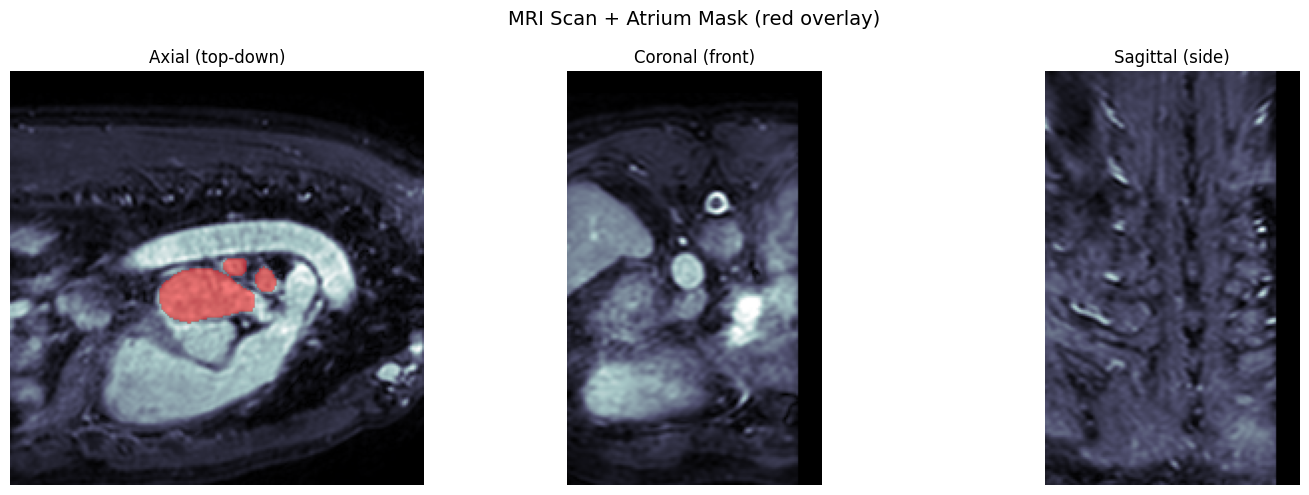

In [23]:
def show_slice(subject, slice_idx=50):
    mri   = subject["mri"]["data"][0]
    label = subject["label"]["data"][0]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    views = {
        "Axial (top-down)"  : (mri[:,:,slice_idx],   label[:,:,slice_idx]),
        "Coronal (front)"   : (mri[:,slice_idx,:],   label[:,slice_idx,:]),
        "Sagittal (side)"   : (mri[slice_idx,:,:],   label[slice_idx,:,:]),
    }
    for ax, (title, (img, msk)) in zip(axes, views.items()):
        ax.imshow(img, cmap="bone")
        masked = np.ma.masked_where(msk == 0, msk)
        ax.imshow(masked, alpha=0.5, cmap="autumn")
        ax.set_title(title)
        ax.axis("off")

    plt.suptitle("MRI Scan + Atrium Mask (red overlay)", fontsize=14)
    plt.tight_layout()
    plt.show()

show_slice(val_dataset[0], slice_idx=50)

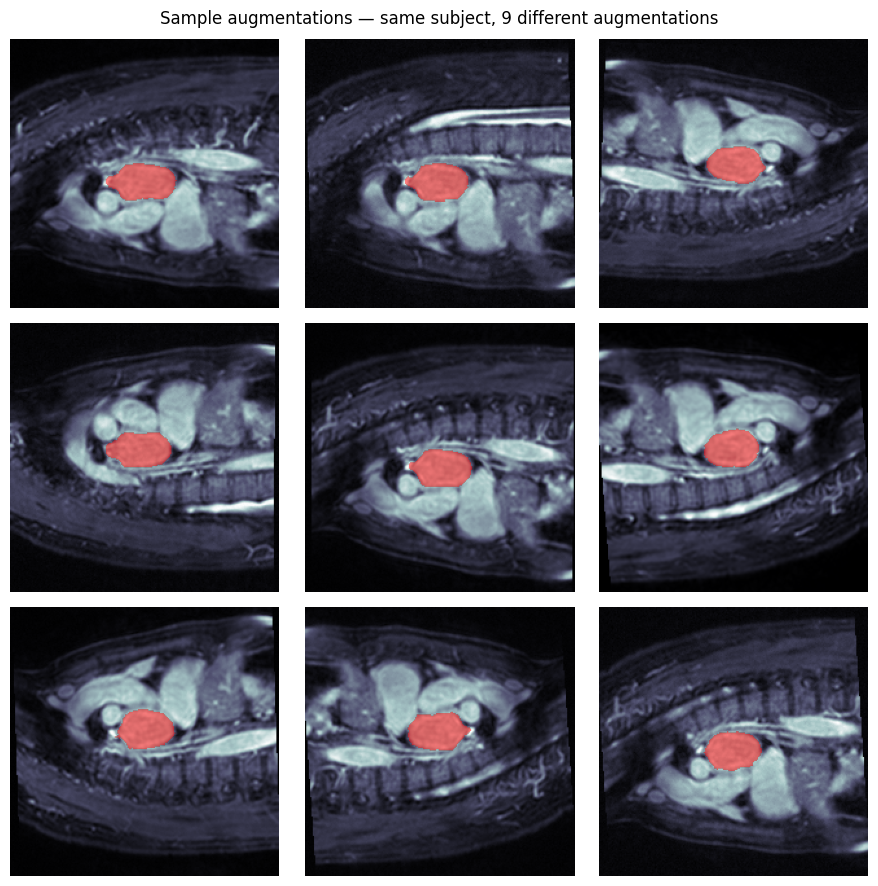

In [24]:

fig, axes = plt.subplots(3, 3, figsize=(9, 9))

for i in range(3):
    for j in range(3):
        sample = train_dataset[3]
        mri    = sample["mri"]["data"]
        mask   = sample["label"]["data"]

        d = mri.shape[-1] // 2

        slice_2d = mri[0, :, :, d]
        mask_2d  = mask[0, :, :, d]

        mask_ = np.ma.masked_where(mask_2d == 0, mask_2d)

        axes[i][j].imshow(slice_2d, cmap="bone")
        axes[i][j].imshow(mask_, alpha=0.5, cmap="autumn")
        axes[i][j].axis("off")

fig.suptitle("Sample augmentations — same subject, 9 different augmentations", fontsize=12)
plt.tight_layout()
plt.show()

# **Model**

In [25]:
!pip install monai pytorch-lightning -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 60.1 MB/s eta 0:00:00


In [26]:

from monai.networks.nets import UNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
import pytorch_lightning as pl
from torch.utils.data import DataLoader, Dataset
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger

In [60]:
class AtriumDataset(Dataset):
    def __init__(self, subjects_dataset):
        self.dataset = subjects_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        mri    = sample["mri"]["data"]
        label  = sample["label"]["data"]
        return mri, label

In [61]:
train_loader  = DataLoader(AtriumDataset(train_dataset), batch_size=1, num_workers=0, shuffle=True)
val_loader    = DataLoader(AtriumDataset(val_dataset),   batch_size=1, num_workers=0, shuffle=False)

In [72]:
def build_model():
    return UNet(
        spatial_dims=3,
        in_channels=1,
        out_channels=1,
        channels=(32,64,128,256,512),
        strides=(2,2,2,2),
        num_res_units=2,
        dropout=0.1,
    )

In [79]:
class AtriumSegmentation(pl.LightningModule):
    def __init__(self,lr=1e-4):
        super().__init__()
        self.save_hyperparameters()

        self.model = build_model()
        self.loss = DiceCELoss(sigmoid=True,lambda_dice=0.7,lambda_ce=0.3)

        self.metrics = DiceMetric(include_background=True,reduction="mean")

    def forward(self,x):
        return self.model(x)

    def training_step(self,batch,batch_idx):
        mri, label = batch
        label = label.float()
        pred = self.model(mri)
        loss = self.loss(pred,label)

        self.log("train dice loss",loss,prog_bar=True)

        if batch_idx % 50 ==0:
            self.log_images(mri.cpu(),pred.cpu(),label.cpu(),"train")

        return loss

    def validation_step(self,batch,batch_idx):
        mri, label = batch
        label = label.float()
        pred = self.model(mri)
        loss = self.loss(pred,label)

        pred_binary = (torch.sigmoid(pred) > 0.5).float()
        self.metrics(pred_binary, label)

        self.log("val dice loss",loss,prog_bar=True)

        if batch_idx % 2 == 0:
            self.log_images(mri.cpu(),pred.cpu(),label.cpu(),"val")

        return loss

    def on_validation_epoch_end(self):
        dice_score = self.metrics.aggregate().item()
        self.metrics.reset()
        self.log("val dice score",dice_score,prog_bar=True)
        print(f"Val dice score: {dice_score:.4f}")

    def log_images(self,mri,pred,mask,name):
        d = mri.shape[-1] // 2
        pred_binary = (torch.sigmoid(pred) > 0.5).float()

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        axes[0].imshow(mri[0, 0, :, :, d],  cmap="bone")
        gt = np.ma.masked_where(mask[0, 0, :, :, d] == 0,
                                mask[0, 0, :, :, d])
        axes[0].imshow(gt, alpha=0.6, cmap="autumn")
        axes[0].set_title("Ground Truth")
        axes[0].axis("off")

        axes[1].imshow(mri[0, 0, :, :, d],  cmap="bone")
        pr = np.ma.masked_where(pred_binary[0, 0, :, :, d] == 0,
                                pred_binary[0, 0, :, :, d])
        axes[1].imshow(pr, alpha=0.6, cmap="autumn")
        axes[1].set_title("Prediction")
        axes[1].axis("off")

        plt.suptitle(f"{name} — depth slice {d}", fontsize=12)
        plt.tight_layout()
        self.logger.experiment.add_figure(name, fig, self.global_step)
        plt.close(fig)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.hparams.lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=5
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "monitor": "val dice loss"},
        }

In [80]:
checkpoint_callback = ModelCheckpoint(
    monitor    = "val dice score",
    mode       = "max",
    save_top_k = 3,
    filename   = "best-model",
)

early_stop_callback = EarlyStopping(
    monitor  = "val dice score",
    mode     = "max",
    patience =  15,
)

In [81]:
torch.manual_seed(42)
model = AtriumSegmentation()

In [82]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [83]:
trainer = pl.Trainer(
    accelerator                 = "gpu" if torch.cuda.is_available() else "cpu",
    devices                     = 1,
    max_epochs                  = 150,
    precision  = "16-mixed",
    gradient_clip_val           = 0.5,
    accumulate_grad_batches     = 4,
    logger                      = TensorBoardLogger(save_dir="./logs", name="atrium"),
    callbacks                   = [checkpoint_callback, early_stop_callback],
    log_every_n_steps           = 1,
)

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [ ]:
trainer.fit(model, train_loader, val_loader)

In [65]:
for threshold in [0.3, 0.4, 0.5, 0.6]:
    for mri, label in val_loader:
        mri   = mri.to(device)
        label = label.float().to(device)

        with torch.no_grad():
            pred        = model(mri)
            pred_binary = (torch.sigmoid(pred) > threshold).float()
            pred_binary = keep_largest(pred_binary.cpu())  # cpu for keep_largest
            pred_binary = pred_binary.to(device)           # back to GPU for metric

        dice_metric(pred_binary, label)                    # both on GPU ✅
        hausdorff_metric(pred_binary.cpu(), label.cpu())   # both on CPU ✅

    d = dice_metric.aggregate().item()
    h = hausdorff_metric.aggregate().item()
    dice_metric.reset()
    hausdorff_metric.reset()

    print(f"Threshold {threshold} | Dice: {d:.4f} | HD95: {h:.2f}mm")

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:220: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)


Threshold 0.3 | Dice: 0.0170 | HD95: 143.83mm
Threshold 0.4 | Dice: 0.0170 | HD95: 143.83mm
Threshold 0.5 | Dice: 0.8028 | HD95: 14.02mm
Threshold 0.6 | Dice: 0.8396 | HD95: 13.27mm


# **Evalution**

In [35]:
import shutil
from monai.metrics import DiceMetric, HausdorffDistanceMetric

In [ ]:
src = checkpoint_callback.best_model_path
dst = "/content/drive/MyDrive/Atrium-Segmentation/best-model.ckpt"
shutil.copy(src, dst)
print("Saved to:", dst)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AtriumSegmentation.load_from_checkpoint(
    "/content/drive/MyDrive/Atrium-Segmentation/best-model.ckpt"
)
model.eval()
model.to(device)

In [38]:
dice_metric = DiceMetric(include_background=False, reduction="mean")
hausdorff_metric = HausdorffDistanceMetric(include_background=False, reduction="mean")

In [39]:
from monai.transforms import KeepLargestConnectedComponent

keep_largest = KeepLargestConnectedComponent(applied_labels=[1])

preds_all  = []
labels_all = []

for mri, label in tqdm(val_loader, desc="Evaluating"):
    mri   = mri.to(device)
    label = label.float().to(device)

    with torch.no_grad():
        pred        = model(mri)
        pred_binary = (torch.sigmoid(pred) > 0.5).float()
        pred_binary = keep_largest(pred_binary.cpu()).to(device)

    dice_metric(pred_binary, label)
    hausdorff_metric(pred_binary.cpu(), label.cpu())

    preds_all.append(pred_binary.cpu())
    labels_all.append(label.cpu())

dice_score      = dice_metric.aggregate().item()
hausdorff_score = hausdorff_metric.aggregate().item()
dice_metric.reset()
hausdorff_metric.reset()

print(f"Dice score: {dice_score:.4f}")
print(f"Hausdorff distance: {hausdorff_score:.4f}")

Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:220: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)


Dice score: 0.8028
Hausdorff distance: 14.0177


Running inference:  33%|███▎      | 1/3 [00:01<00:03,  1.62s/it]

Subject 01 | Dice: 0.7789


Running inference:  67%|██████▋   | 2/3 [00:02<00:01,  1.36s/it]

Subject 02 | Dice: 0.8333


Running inference: 100%|██████████| 3/3 [00:03<00:00,  1.32s/it]

Subject 03 | Dice: 0.7961


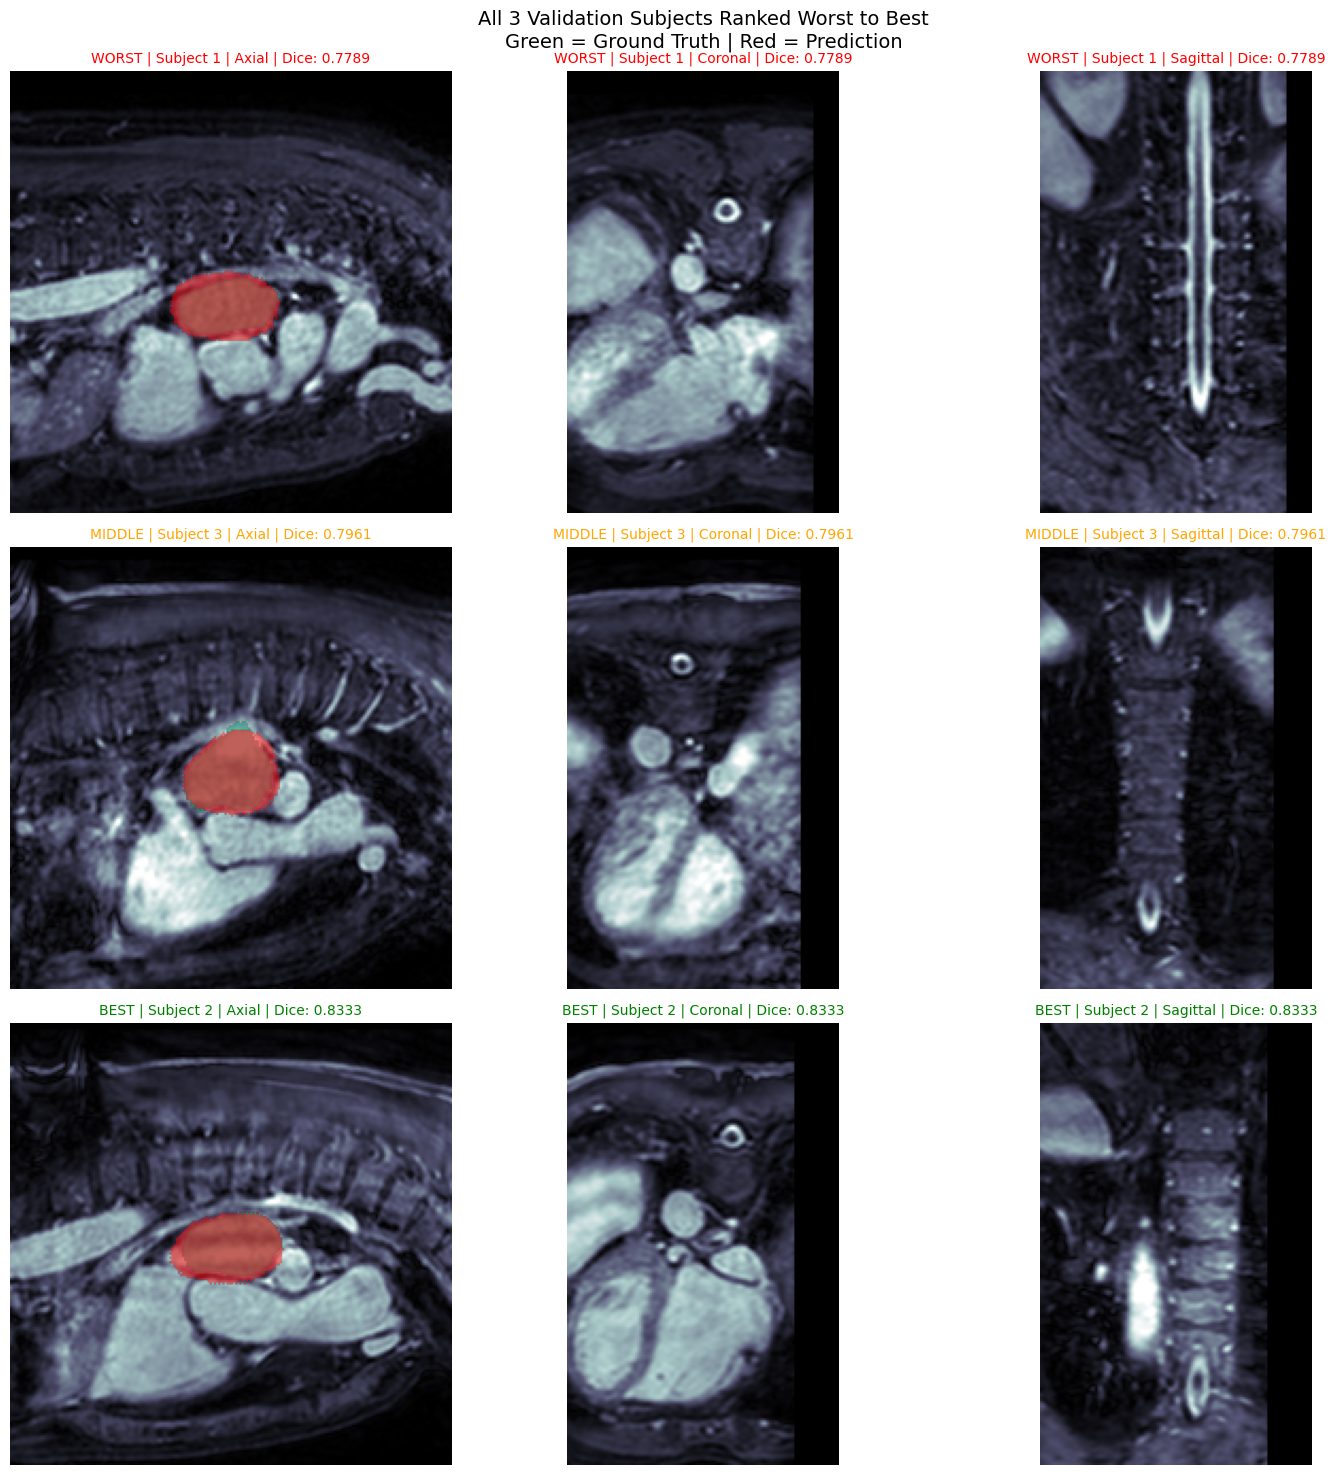


Rankings
─────────────────────────────────────────────
[WORST] | Subject 1 | Dice: 0.7789
[MID]   | Subject 3 | Dice: 0.7961
[BEST]  | Subject 2 | Dice: 0.8333
─────────────────────────────────────────────
Mean Dice : 0.8028
Saved     : predictions_ranked.png


In [51]:
from tqdm import tqdm
from monai.transforms import KeepLargestConnectedComponent

keep_largest = KeepLargestConnectedComponent(applied_labels=[1])

all_results = []

for idx, (mri, label) in enumerate(tqdm(val_loader, desc="Running inference")):
    mri_input = mri.to(device)
    label_f   = label.float()

    with torch.no_grad():
        pred        = model(mri_input)
        pred_binary = (torch.sigmoid(pred) > 0.5).float().cpu()
        pred_binary = keep_largest(pred_binary)

    intersection = (pred_binary * label_f).sum()
    dice         = (2 * intersection / (pred_binary.sum() + label_f.sum() + 1e-8)).item()

    all_results.append({
        "idx"  : idx,
        "mri"  : mri[0, 0],
        "label": label_f[0, 0],
        "pred" : pred_binary[0, 0],
        "dice" : dice,
    })

    print(f"Subject {idx+1:02d} | Dice: {dice:.4f}")

all_results = sorted(all_results, key=lambda x: x["dice"])

n    = len(all_results)
fig, axes = plt.subplots(n, 3, figsize=(15, 5 * n))

if n == 1:
    axes = axes[np.newaxis, :]

for row, result in enumerate(all_results):
    mri   = result["mri"]
    label = result["label"]
    pred  = result["pred"]
    dice  = result["dice"]

    atrium_slices = [i for i in range(label.shape[-1])
                     if label[:,:,i].sum() > 0]
    d = atrium_slices[len(atrium_slices)//2] if atrium_slices else mri.shape[-1]//2

    views = [
        ("Axial",    mri[:,:,d],  label[:,:,d],  pred[:,:,d]),
        ("Coronal",  mri[:,d,:],  label[:,d,:],  pred[:,d,:]),
        ("Sagittal", mri[d,:,:],  label[d,:,:],  pred[d,:,:]),
    ]

    if row == 0:
        rank_label = "WORST"
        color      = "red"
    elif row == n - 1:
        rank_label = "BEST"
        color      = "green"
    else:
        rank_label = "MIDDLE"
        color      = "orange"

    for col, (view_name, img, gt, pr) in enumerate(views):
        ax = axes[row][col]
        ax.imshow(img, cmap="bone")

        gt_masked = np.ma.masked_where(gt == 0, gt)
        ax.imshow(gt_masked, alpha=0.5, cmap="summer")

        pr_masked = np.ma.masked_where(pr == 0, pr)
        ax.imshow(pr_masked, alpha=0.5, cmap="autumn")

        ax.set_title(
            f"{rank_label} | Subject {result['idx']+1} "
            f"| {view_name} | Dice: {dice:.4f}",
            color=color, fontsize=10
        )
        ax.axis("off")

plt.suptitle(
    f"All {n} Validation Subjects Ranked Worst to Best\n"
    "Green = Ground Truth | Red = Prediction",
    fontsize=14
)
plt.tight_layout()
plt.savefig("predictions_ranked.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"\nRankings")
print(f"{'─'*45}")
for rank, result in enumerate(all_results):
    tag = "[WORST]" if rank == 0 else "[BEST] " if rank == n-1 else "[MID]  "
    print(f"{tag} | Subject {result['idx']+1} | Dice: {result['dice']:.4f}")
print(f"{'─'*45}")
print(f"Mean Dice : {np.mean([r['dice'] for r in all_results]):.4f}")
print(f"Saved     : predictions_ranked.png")

In [85]:
!pip install celluloid -q
!apt-get install -y ffmpeg -q

Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.
